1 Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fijar semilla para reproducibilidad
np.random.seed(42)

2 Generación del dataset ficticio

In [ ]:
# Generar 50 muestras de horas de estudio (entre 1 y 10 horas)
horas_estudio = np.random.uniform(1, 10, 50)

# Generar notas con una relación lineal + ruido aleatorio
ruido = np.random.normal(0, 0.7, 50)
notas = 2.0 + 0.75 * horas_estudio + ruido

# Asegurar que las notas se mantengan en la escala acotada de 1 a 10
notas = np.clip(notas, 1.0, 10.0)

# Crear DataFrame con pandas
df = pd.DataFrame({
    "Horas_Estudio": horas_estudio,
    "Nota_Examen": notas
})

print("Primeros 5 registros:")
print(df.head())

Primeros 5 registros:
   Horas_Estudio  Nota_Examen
0       4.370861     5.795072
1       9.556429     9.287279
2       7.587945     7.610005
3       6.387926     6.580172
4       2.404168     2.768160


3 Gráfico de dispersión inicial

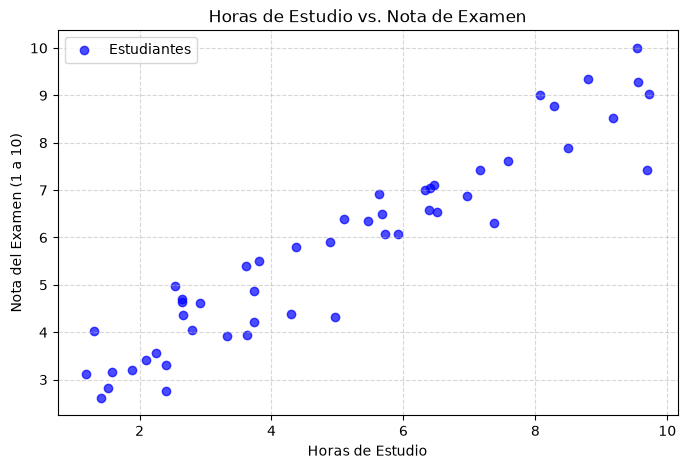

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Horas_Estudio"], df["Nota_Examen"], color="blue", alpha=0.7, label="Estudiantes")
plt.title("Horas de Estudio vs. Nota de Examen")
plt.xlabel("Horas de Estudio")
plt.ylabel("Nota del Examen (1 a 10)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

4 División en Entrenamiento (80%) y Prueba (20%)

In [ ]:
# Separar la variable independiente X de la variable dependiente y [1, 2]
X = df[["Horas_Estudio"]].values
y = df["Nota_Examen"].values

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

5 Entrenamiento del modelo

In [ ]:
# Instanciar y ajustar la regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Extraer el valor escalar con [0]
pendiente = modelo.coef_[0]
interseccion = modelo.intercept_

print(f"Ecuación obtenida: y = {pendiente:.4f} * X + {interseccion:.4f}")
print(f"Por cada hora adicional de estudio, la nota aumenta en promedio {pendiente:.2f} puntos.")

Ecuación obtenida: y = 0.7246 * X + 2.1213
Por cada hora adicional de estudio, la nota aumenta en promedio 0.72 puntos.


6 Visualización de la recta de regresión

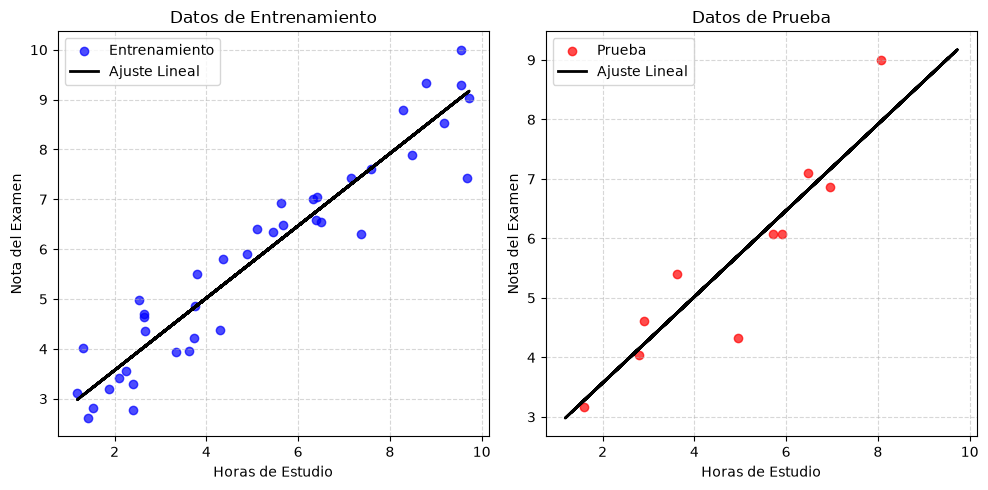

In [ ]:
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

plt.figure(figsize=(10, 5))

# Gráfico conjunto de Entrenamiento
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color="blue", alpha=0.7, label="Entrenamiento")
plt.plot(X_train, y_pred_train, color="black", linewidth=2, label="Ajuste Lineal")
plt.title("Datos de Entrenamiento")
plt.xlabel("Horas de Estudio")
plt.ylabel("Nota del Examen")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Gráfico conjunto de Prueba
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color="red", alpha=0.7, label="Prueba")
plt.plot(X_train, y_pred_train, color="black", linewidth=2, label="Ajuste Lineal")
plt.title("Datos de Prueba")
plt.xlabel("Horas de Estudio")
plt.ylabel("Nota del Examen")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

7 Evaluación con métricas de regresión

In [ ]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("--- Evaluación en Datos de Prueba ---")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Puntuación R2 (Coeficiente de Determinación): {r2:.4f}")

--- Evaluación en Datos de Prueba ---
Error Absoluto Medio (MAE): 0.4787
Error Cuadrático Medio (MSE): 0.3912
Puntuación R2 (Coeficiente de Determinación): 0.8541


8 Predicción sobre estudiantes nuevos

In [ ]:
horas_nuevas = np.array([[3.0], [6.5], [8.0]])
predicciones = modelo.predict(horas_nuevas)

for hrs, nota in zip(horas_nuevas.ravel(), predicciones):
    nota_final = min(max(nota, 1.0), 10.0)
    print(f"Estudiando {hrs} hs -> Nota estimada: {nota_final:.2f}")

Estudiando 3.0 hs -> Nota estimada: 4.30
Estudiando 6.5 hs -> Nota estimada: 6.83
Estudiando 8.0 hs -> Nota estimada: 7.92
